# Time Series 101
Using time series analysis aims to understand time-ordered datasets, such as temperatures throughout the year. In a time-ordered set, data points may well effect those that come after so it is important we only consider them in the order taken. In this notebook we will go over some of the starting ideas and analysis points to get you started with understanding time-series data and what it can be used to achieve. <br>
We will largely be using statsmodels, a python library that handles statistical tests very well. This notebook assumes you have some basic python knowledge including: plotting graphs, data wrangling principles, and function writing. Explanations will be made along the way, however, so this should be fine for beginners to python.

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import acf, pacf, adfuller

%matplotlib inline

# Data Generation and Starting Concepts
Here we look at some simple examples of how we can model our own time series dataset and do some investigation.

## Random Walk
Random walk is method of generating time series data by calculating the cumulutive sum of some generated data. The random walk is so named, because we generate random numbers to produce it. Usually we use some number of generated values taken from a normal distribution (these are numbers that have a mean of 0 and standard deviation of 1 so that x $\epsilon$ [-1, 1]. <br>
The cumulative sum gives us the running value of our dataset. For an array [1, -5, 2, -1, 6] the cumulutive sum would be: 1+(-5)+2+(-1)+6 = +3. The cumulative sum is stored at every step so that we get an array of values 

In [143]:
steps = np.random.standard_normal(1000) #Generate 1000 random numbers from a standard normal distribution
steps[0] = 0 #Set the first value to 0 because it looks nice
random_walk = np.cumsum(steps) #Calculate the cumulative sum

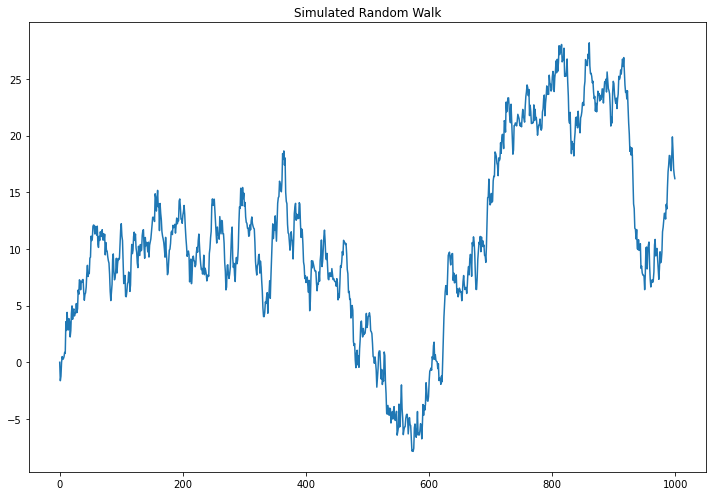

In [144]:
#Plot the random walk
plt.figure(figsize=(10, 7))
plt.plot(random_walk)
plt.title('Simulated Random Walk')
plt.show()

### Augmented Dickey-Fuller Test 
The Dickey-Fuller test tests the null-hypothesis that a unit root is present in an autoregressive time series model. In lay terms, this test will see whether our time series is actually dependent on time (non-stationary), or not (stationary). <br>
Autoregressive (AR) refers to the fact that a time series is linearly dependent on previous elements (ie one value at a point in time is dependent on the one before it etc). The characteristic equation for this is: $y_t=\mu + \sum_{j=1}^{p}\phi_j(y_{t-j}-\mu)+z_t$ where: $t$ is time step (current second, week, month etc), $y_t$ is output at time $t$, $\mu$ is the mean of the dataset, $\phi$ is some weight, and $z_t$ is error at time $t$. $p$ is the order of the process, and a simple example would be order 1: $y_t = \rho y_{t-1} + z_t$. Here $\rho$ is a coefficient. If we write this as the change in $y$ over time, we write as: $\Delta y_t=(\rho-1)y_{t-1}+z_t$. If we have a unit root - such that $\rho = 1$ - then we have a difference equal to the error in the data. Since the error is going to change over time, so will the data distribution, so we have non-stationary time series data. If the opposite is true, then the error stays (pretty much) the same over time, so we can shift the whole distribution forward or back and get the same looking thing. <br>
The augmented version is only a little more complicated and applies a coefficient to the time trend which allows us to see if the time trend is actually constant or not. <br>
When we perform the ADF test, we are looking at a few key numbers:<br>
- ADF Statistic: the more negative this number, the more likely it is that we reject the null-hypothesis that there is a unit root (non-stationary) and accept the alternative that there isn't (stationary) 
- p-value: the probability that another similar value will arise because of statistical effects. You choose some value - known as alpha ($\alpha$) - and compare this number to that. A common choice would be 0.05 so that a p-value above this would mean we accept the null-hypothesis 
    - 0.05 here alludes to you being 95% sure that this is the case. 0.01 would mean you are 99% etc etc
- lags used: how many time steps you use. If you use 365 lags for a year's worth of data, you are taking it one day at a time!
- The critical values: these are the values that, if the ADF statistic is higher than, indicate the strength of stationarity. The percentages refer to the $\alpha$ you chose <br>

It is worth understanding this, so take time with it!

In [145]:
random_adf = adfuller(random_walk) # We can set the number of lags used ourselves if we wish (more on this later) 
print('ADF statistic: %.6f; p-value: %.14f; lags used: %d' % (random_adf[0], random_adf[1], random_adf[2]))
print('Critical Values: {}'.format(random_adf[4]))

ADF statistic: -2.084865; p-value: 0.25064370048190; lags used: 0
Critical Values: {'1%': -3.4369127451400474, '5%': -2.864437475834273, '10%': -2.568312754566378}


We can see that the p-value is much greater than 0.05, so this is clearly a non-stationary dataset. This is not surprising considering that each step in the random walk cumulative sum depends on the previous, as the next step in our time series is the value of the sum of all the previous! 

### Differencing 
Non-stationary time series data usually have three components to them: seasonal, trend, and residual (error or noise). Seasonal elements are those that appear periodically. An example would be taking the time series of temperature in the UK, which will have a seasonal element based on...the seasons! Trend refers to some kind of possible trend in the data. Again, if we take a look at the temperature of the UK, we are likely to see an upward trend in the last 150 years because of climate change. Both of these may not exist in the same dataset, so we can say that some time series may well be trend-stationary or seasonal-stationary ie no trend or no seasonal, but still non-stationary overall. <br>
If we wish to make a non-stationary trend into something that is stationary, we can apply differencing. This can take multiple different forms. For instance, we can subtract the seasonal and trend data from the output and get the residual, or divide by them to get the residual etc. One of the simpler ways is to take the difference of each point from the one previous and plot this. This should give us the error that we have. <br>
To illustrate why, we can look at our simple model from discussions on the ADF test: $y_t = \rho y_{t-1} + z_t$. If we set $\rho = 1$ then, as previously mentioned, we have a non-stationary time series. Rearranging this will give us: $y_t - y_{t-1} = z_t$ which is us taking the point previous from the current. You can see that this gives us just the residual. If we were to integrate this over all the time we have, we would find that the dependency on time goes away, and we arrive at a stationary dataset. <br>
Differencing allows us to use techniques that only work with stationary data on our time series that is non-stationary.

In [150]:
random_walk_diff = np.diff(random_walk, n=1) #calculate difference

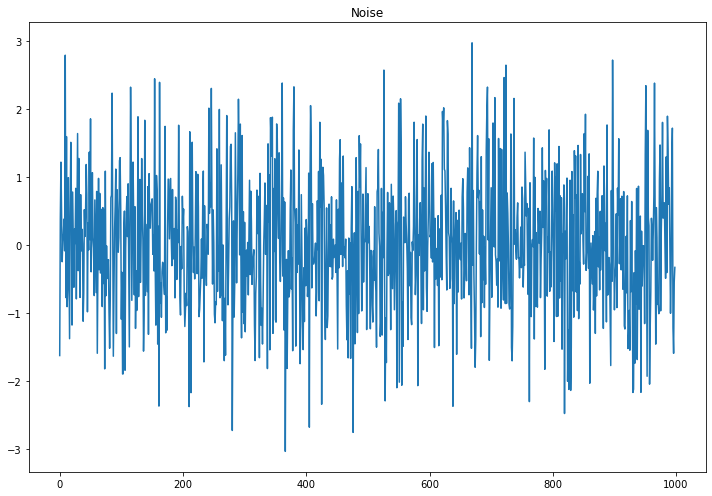

In [151]:
plt.figure(figsize=(10, 7))
plt.plot(random_walk_diff)
plt.title('Noise')
plt.show()

In [152]:
noise_adf = adfuller(random_walk_diff)
print('ADF statistic: %.6f; p-value: %.14f; lags used: %d' % (noise_adf[0], noise_adf[1], noise_adf[2]))
print('Critical Values: {}'.format(noise_adf[4]))

ADF statistic: -31.869991; p-value: 0.00000000000000; lags used: 0
Critical Values: {'1%': -3.4369193380671, '5%': -2.864440383452517, '10%': -2.56831430323573}


Whilst the graph is clearly showing a stationary dataset, it's always useful to explore a statistical description, hence the ADF here. Notice the hugely negative statistic and very small p-value (it won't be truly 0, this is a rounding problem!), so we can reject the null hypothesis that this is non-stationary, and accept the alternative that it is.

### ACF and PACF
Autocorrelation and Partial Autocorrelation Functions are used to see the relationships with observations in time series and observations at previous steps. ADF actually uses these in it's set up. We use this to test for the correlations between variables over time. This is only useful if we have stationary datasets. The reason for this is that non-stationary datasets have a dependence on time. This being the case, time is no longer an independent variable, but becomes a dependent one (ie as it changes, the distribution changes). Basically, if time itself causes the distribution to change, how can you test how correlated two variables are over time? What if they aren't, but the time variable changes the distribution such that it looks like they are? <br>
ACF is different to PACF as ACF considers changes in some variable from any number of others. PACF considers only changes between the variables you are directly testing. The test will output values of correlation between -1 and 1 showing strength of correlation, and whether it is negative or positive. Choosing number of lags will allow you to see how this changes over time steps. The function in statstools also automatically draws a confidence band set at 95%. This shows that any effects outside this band are likely because of actual effects, rather than statistical randomness. <br>
You may wonder why you would ever use ACF if PACF is more specific. Well, imagine you want to test effects on plant growth. Over time plant growth stays pretty constant, so likely to be stationary. You run an ACF on plant growth vs oxygen intake, and you get a lot of values close to 1, showing correlation. Your PACF shows no correlation (within our confidence band). This means there could be other effects (sunlight etc) instead, and you can rule out oxygen.

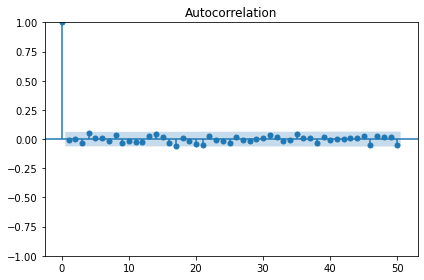

In [153]:
plot_acf(random_walk_diff, lags=50);

C:\Users\Joe_Davies\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


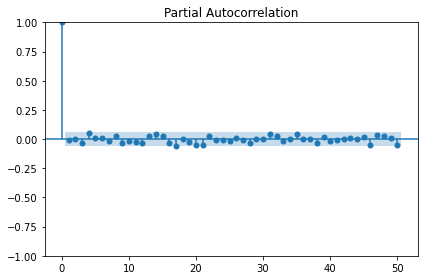

In [154]:
plot_pacf(random_walk_diff, lags=50);

These graphs show us that all points fall in that error band, so we are nice and stationary. You will notice that the first point in both seems hugely correlated. This is a consequence of the fact that we have, at this stage, only taken one time frame, so everything is significantly correlated. It would be like trying to extrapolate how tall someone is going to be by taking their height difference from the age of 5 to 6 only!

## Moving Average (MA(q))
Similar to AR models, but with the difference that we don't focus on the output at time $t$. Instead we look at the errors directly ie: $y_t=\mu+z_t+\sum^q_{j=1}\phi_jz_{t-j}$. This has the benefit of giving us a good model of some stationary data, as we expect that the output is only dependent on noise here.

In [12]:
#set the order
ar2 = np.array([2])
#set the weights
ma2 = np.array([1., 0.9, 0.3])

A note should be made here about the usual process of this. We are going to use the ARMA process which stands for AutoRegressive-Moving Average. This essentially adds the two functions together so that we get: $y_t=\mu+z_t+\sum_{j=1}^p\phi_j(y_{t-j}-\mu)+\sum_{j=1}^q\theta_jz_{t-j}$ where we have: $p$ AR terms and $q$ MA terms. We also have different weights for each, so we use both $\phi$ and $\theta$.

In [13]:
MA2_process = ArmaProcess(ar2, ma2).generate_sample(nsample=1000)

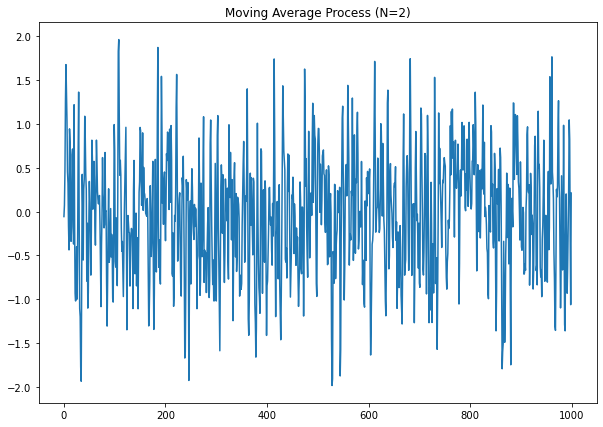

In [14]:
plt.figure(figsize=(10, 7))
plt.plot(MA2_process)
plt.title('Moving Average Process (N=2)')
plt.show()

In [124]:
ma2_adf = adfuller(MA2_process)
print('ADF statistic: %.6f; p-value:%.14f; lags used: %d' % (ma2_adf[0], ma2_adf[1], ma2_adf[2]))
print('Critical Values: {}'.format(ma2_adf[4]))

ADF statistic: -11.822126; p-value:0.00000000000000; lags used: 5
Critical Values: {'1%': -3.43694584277544, '5%': -2.8644520725172873, '10%': -2.5683205291305176}


We can clearly see that we have stationary data. Notice that lags used is 5, so if we set the number of lags we use in ACF and PACF, we should find that, within that value, we reach the confidence band (and we do!)

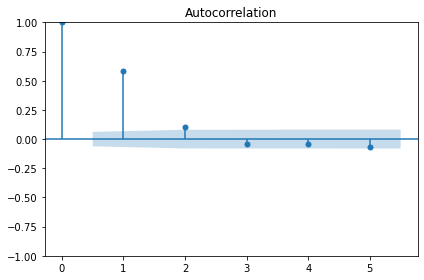

In [130]:
plot_acf(MA2_process, lags=5);

C:\Users\Joe_Davies\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


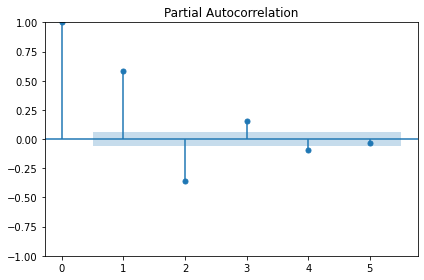

In [129]:
plot_pacf(MA2_process, lags=5);

# Using Real Data
We can now try this with a real dataset! Here we use some RNLI data. We are going to be looking at whether assists, rescues and combined total are stationary or not.

In [17]:
df_main = pd.read_csv('C:/Users/Joe_Davies/Documents/Analysis/data/LG_data.csv')
df_main

,ROSNumber,Date,Year,Month_text,Month_number,Weekday,Hour,Assistance,Rescue,WaveHeight,HighOrLowWater,EbbOrFlood,WindForce,WindForceNum
0,LGI02056/2017,22/10/2017 11:05,2017,October,10,Sunday,11,0,1,Unknown,Unknown,Unknown,Unknown,99
1,LGI04589/2017,08/07/2017 15:05,2017,July,7,Saturday,15,1,0,0.0 - 0.5m,Unknown,Unknown,Unknown,99
2,LGI02063/2017,22/10/2017 13:25,2017,October,10,Sunday,13,1,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99
3,LGI02063/2017,22/10/2017 13:25,2017,October,10,Sunday,13,1,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99
4,LGI02063/2017,22/10/2017 13:25,2017,October,10,Sunday,13,1,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29074,LGI00510/2022,18/06/2022 14:05,2022,June,6,Saturday,14,1,0,0.0 - 0.5m,Unknown,Flooding,3 Gentle breeze (7-10 knots),3
29075,LGI00520/2022,22/04/2022 12:50,2022,April,4,Friday,12,1,0,0.5 - 1.0m,Unknown,Flooding,3 Gentle breeze (7-10 knots),3
29076,LGI00520/2022,22/04/2022 12:50,2022,April,4,Friday,12,1,0,0.5 - 1.0m,Unknown,Flooding,3 Gentle breeze (7-10 knots),3
29077,LGI00520/2022,22/04/2022 12:50,2022,April,4,Friday,12,1,0,0.5 - 1.0m,Unknown,Flooding,3 Gentle breeze (7-10 knots),3


In [170]:
df_date = df_main.set_index('Date') #set the index to be date
df_date.index = pd.to_datetime(df_main.Date).dt.normalize() #normalize the date so it only shows day, month and year

In [171]:
df_date

,ROSNumber,Year,Month_text,Month_number,Weekday,Hour,Assistance,Rescue,WaveHeight,HighOrLowWater,EbbOrFlood,WindForce,WindForceNum
Date,,,,,,,,,,,,,
2017-10-22,LGI02056/2017,2017,October,10,Sunday,11,0,1,Unknown,Unknown,Unknown,Unknown,99
2017-08-07,LGI04589/2017,2017,July,7,Saturday,15,1,0,0.0 - 0.5m,Unknown,Unknown,Unknown,99
2017-10-22,LGI02063/2017,2017,October,10,Sunday,13,1,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99
2017-10-22,LGI02063/2017,2017,October,10,Sunday,13,1,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99
2017-10-22,LGI02063/2017,2017,October,10,Sunday,13,1,0,1.5 - 2.0m,Unknown,Unknown,Unknown,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-18,LGI00510/2022,2022,June,6,Saturday,14,1,0,0.0 - 0.5m,Unknown,Flooding,3 Gentle breeze (7-10 knots),3
2022-04-22,LGI00520/2022,2022,April,4,Friday,12,1,0,0.5 - 1.0m,Unknown,Flooding,3 Gentle breeze (7-10 knots),3
2022-04-22,LGI00520/2022,2022,April,4,Friday,12,1,0,0.5 - 1.0m,Unknown,Flooding,3 Gentle breeze (7-10 knots),3


In [172]:
date_range = pd.date_range(start = '2017-01-01', end = '2021-12-31', freq = 'D') #pick a date range

In [168]:
df_date_slice = df_date.pivot_table(values=['Assistance', 'Rescue'], index = df_date.index, aggfunc=np.sum)
df_date_slice['Total'] = df_date_slice.Assistance + df_date_slice.Rescue
df_date_slice

,Assistance,Rescue,Total
Date,,,
2017-01-04,3,2,5
2017-01-05,4,2,6
2017-01-06,19,31,50
2017-01-07,23,6,29
2017-01-08,36,29,65
...,...,...,...
2022-11-05,2,0,2
2022-11-06,1,0,1
2022-12-04,1,0,1


In [174]:
df_date_slice_nona = df_date_slice.reindex(date_range) #slice our data into a date range
df_date_slice_nona = df_date_slice_nona.dropna() #drop any NaN values (can't use these)
df_date_slice_nona

,Assistance,Rescue,Total
2017-01-04,3.0,2.0,5.0
2017-01-05,4.0,2.0,6.0
2017-01-06,19.0,31.0,50.0
2017-01-07,23.0,6.0,29.0
2017-01-08,36.0,29.0,65.0
...,...,...,...
2021-12-04,12.0,2.0,14.0
2021-12-06,60.0,33.0,93.0
2021-12-07,69.0,76.0,145.0
2021-12-08,98.0,97.0,195.0


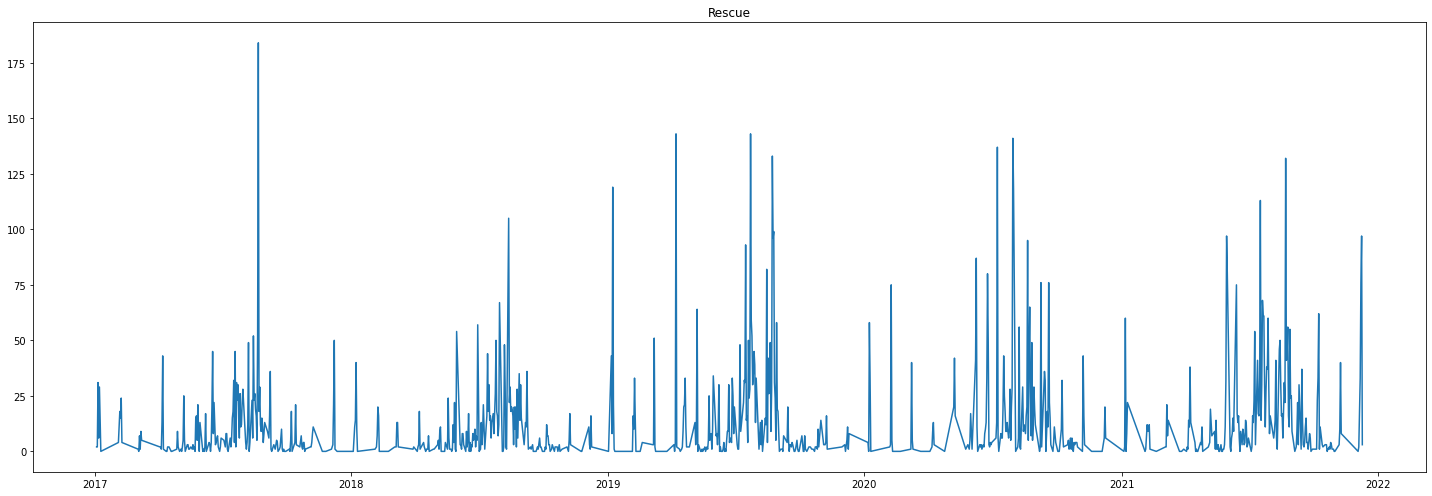

In [176]:
plt.figure(figsize=(20, 7))
plt.title('Rescue')
plt.plot(df_date_slice_nona.Rescue)
plt.show()

Note here that we can no longer allow the function to calculate our number of lags. We can see that there is a seasonal spike in summer (we expect this as more people go to the seaside). It would be best, with 5 years of data, to go monthly. We set the autolag te be None, allowing for us to set the lags ourselves. We do this by setting maxlag to 60. 

In [177]:
res = adfuller(df_date_slice_nona.Rescue, regression = 'n', autolag=None, maxlag=60)

In [178]:
print('Rescue ADF statistic: %.6f; p-value:%.14f; lags used: %d' % (res[0], res[1], res[2]))
print(res[4])

Rescue ADF statistic: -1.516380; p-value:0.12143283400172; lags used: 60
{'1%': -2.5683816003804734, '5%': -1.941321373515409, '10%': -1.6165105250000313}


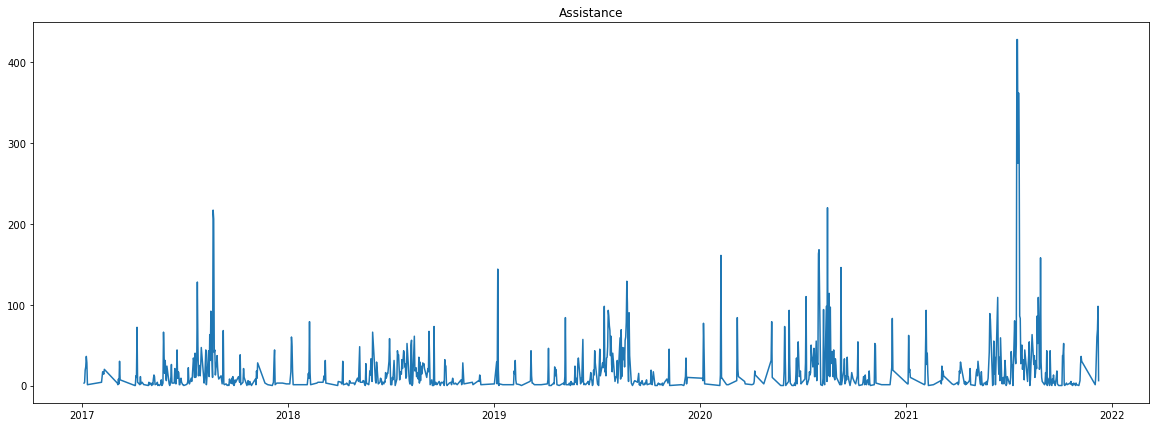

In [26]:
plt.figure(figsize=(20, 7))
plt.title('Assistance')
plt.plot(df_date_slice_nona.Assistance)
plt.show()

In [29]:
ast = adfuller(df_date_slice_nona.Assistance, regression = 'n', autolag = None, maxlag = 60)

In [30]:
print('Assistance ADF statistic: %.6f; p-value:%.14f; lags used: %d' % (ast[0], ast[1], ast[2]))
print(ast[4])

Assistance ADF statistic: -1.890293; p-value:0.05599751817456; lags used: 60
{'1%': -2.5683816003804734, '5%': -1.941321373515409, '10%': -1.6165105250000313}


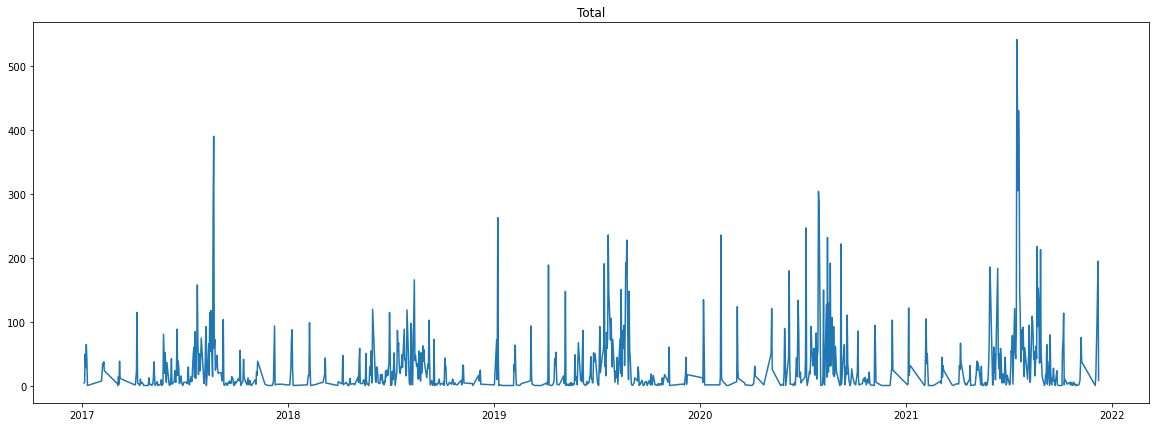

In [33]:
plt.figure(figsize=(20, 7))
plt.title('Total')
plt.plot(df_date_slice_nona.Total)
plt.show()

In [34]:
tot = adfuller(df_date_slice_nona.Total, regression='n', autolag=None, maxlag=60)

In [35]:
print('Total ADF statistic: %.6f; p-value:%.14f; lags used: %d' % (tot[0], tot[1], tot[2]))
print(tot[4])

Total ADF statistic: -1.742297; p-value:0.07728545930845; lags used: 60
{'1%': -2.5683816003804734, '5%': -1.941321373515409, '10%': -1.6165105250000313}


We can clearly see a trend here: seasonal. Even if this dataset is trend-stationary, it is non-stationary, so we need to do some differencing.

### Differencing 

In [37]:
res_diff = np.diff(df_date_slice_nona.Rescue, 1)
ast_diff = np.diff(df_date_slice_nona.Assistance, 1)
tot_diff = np.diff(df_date_slice_nona.Total, 1)

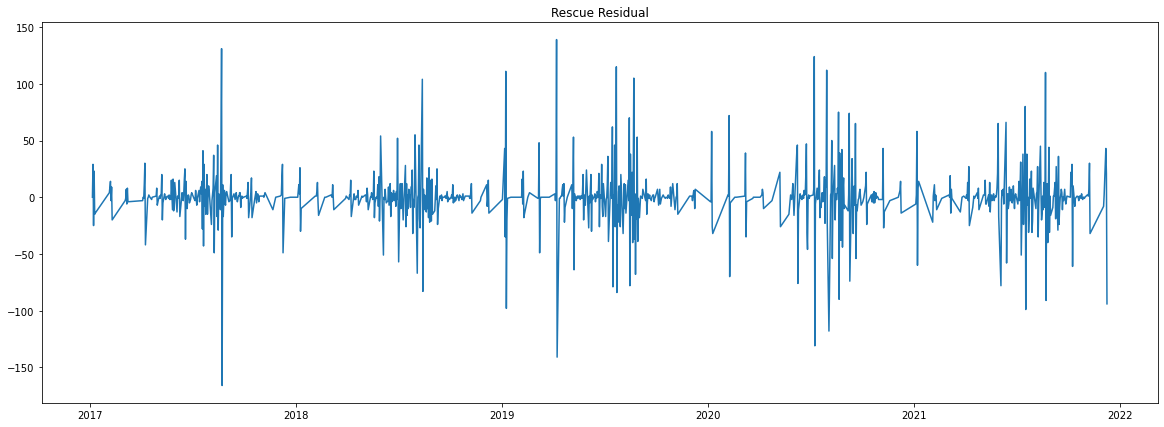

In [44]:
plt.figure(figsize=(20, 7))
plt.title('Rescue Residual')
plt.plot(df_date_slice_nona.index[1:], res_diff)
plt.show()

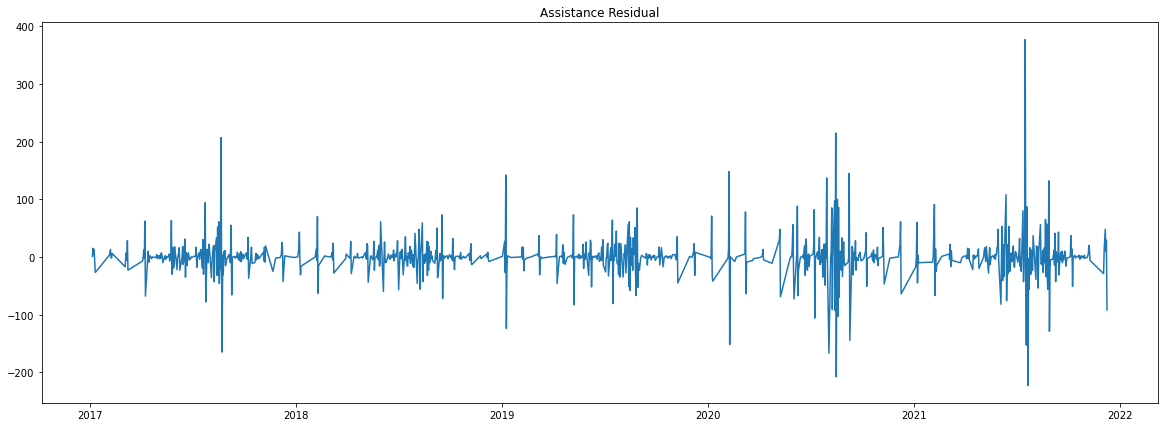

In [45]:
plt.figure(figsize=(20, 7))
plt.title('Assistance Residual')
plt.plot(df_date_slice_nona.index[1:], ast_diff)
plt.show()

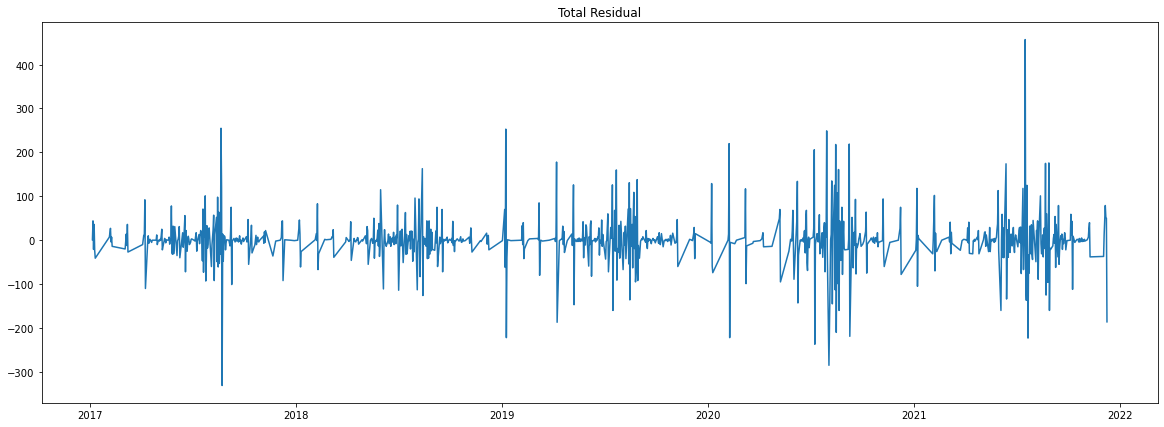

In [46]:
plt.figure(figsize=(20, 7))
plt.title('Total Residual')
plt.plot(df_date_slice_nona.index[1:], tot_diff)
plt.show()

In [47]:
res_diff_adf = adfuller(res_diff, autolag=None, regression='n', maxlag=60)
ast_diff_adf = adfuller(ast_diff, autolag=None, regression='n', maxlag=60)
tot_diff_adf = adfuller(tot_diff, autolag=None, regression='n', maxlag=60)

In [49]:
print('Rescue Residual ADF statistic: %.6f; p-value:%.14f; lags used: %d' % (res_diff_adf[0], res_diff_adf[1], res_diff_adf[2]))
print(res_diff_adf[4])
print('Assistance Residual ADF statistic: %.6f; p-value:%.14f; lags used: %d' % (ast_diff_adf[0], ast_diff_adf[1], ast_diff_adf[2]))
print(ast_diff_adf[4])
print('Total Residual ADF statistic: %.6f; p-value:%.14f; lags used: %d' % (tot_diff_adf[0], tot_diff_adf[1], tot_diff_adf[2]))
print(tot_diff_adf[4])

Rescue Residual ADF statistic: -5.095876; p-value:0.00000068465490; lags used: 60
{'1%': -2.5683847251149623, '5%': -1.9413217583511693, '10%': -1.6165101639849921}
Assistance Residual ADF statistic: -5.242181; p-value:0.00000034999404; lags used: 60
{'1%': -2.5683847251149623, '5%': -1.9413217583511693, '10%': -1.6165101639849921}
Total Residual ADF statistic: -5.095698; p-value:0.00000068520967; lags used: 60
{'1%': -2.5683847251149623, '5%': -1.9413217583511693, '10%': -1.6165101639849921}


Each of these are now nice and stationary!

### ACF and PACF 

C:\Users\Joe_Davies\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(
C:\Users\Joe_Davies\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(
C:\Users\Joe_Davies\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


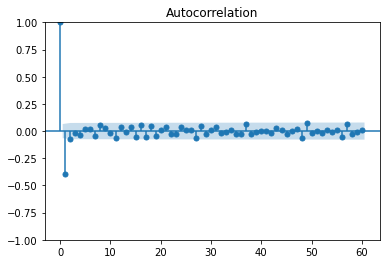

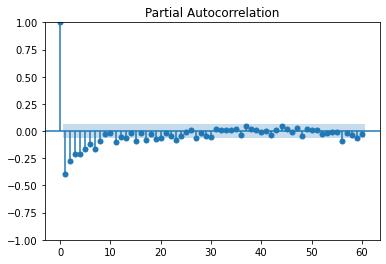

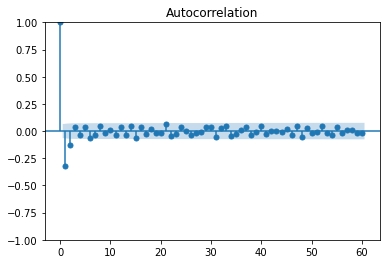

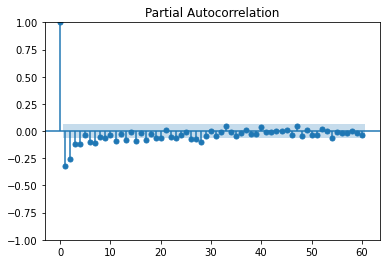

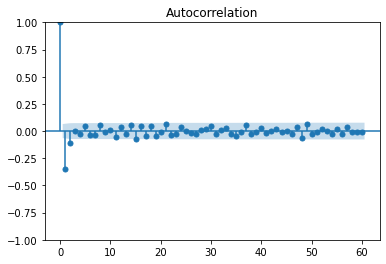

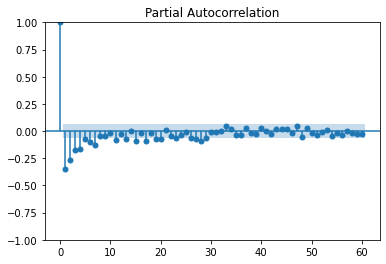

In [59]:
diff_sets = [res_diff, ast_diff, tot_diff]
for diff in diff_sets:
    plot_acf(diff, lags=60);
    plot_pacf(diff, lags=60);

We can see that over the 60 months, we definitely have stationary data!

# Functionalizing the Above
It's always good practice to turn any piece of code that you are going to be repeating into a function, so you needn't write it again. Below are ready to use functions for the key processes.

In [90]:
def adf_test(data, alpha = 0.05, lags = 60):
    adf = adfuller(data, autolag=None, regression='n', maxlag=60)
    print('ADF statistic: %.6f; p-value:%.14f; lags used: %d' % (adf[0], adf[1], adf[2]))
    print('Critical Values: {}'.format(res_diff_adf[4]))
    if adf[1] < alpha:
        print('Data is STATIONARY')
        return True
    else:
        print('Data is NON-STATIONARY')
        return False

In [81]:
temp1 = adf_test(df_date_slice_nona.Rescue)
print('####################################################################')
temp2 = adf_test(res_diff)

ADF statistic: -1.516380; p-value:0.12143283400172; lags used: 60
Critical Values: {'1%': -2.5683847251149623, '5%': -1.9413217583511693, '10%': -1.6165101639849921}
Data is Non-Stationary
####################################################################
ADF statistic: -5.095876; p-value:0.00000068465490; lags used: 60
Critical Values: {'1%': -2.5683847251149623, '5%': -1.9413217583511693, '10%': -1.6165101639849921}
Data is Stationary


We include the return values here so that we can use them for a full analysis function.

In [82]:
print(temp1, temp2)

False True


In [73]:
def acf_pacf_plotter(data, lags = 60):
    plt.rcParams['figure.figsize'] = [10, 7]
    plt.rcParams['figure.autolayout'] = True
    plot_acf(data, lags=lags);
    plot_pacf(data, lags=lags);

C:\Users\Joe_Davies\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


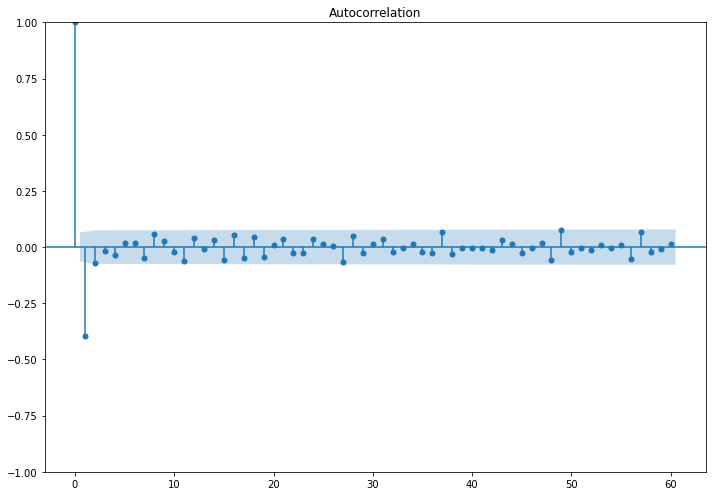

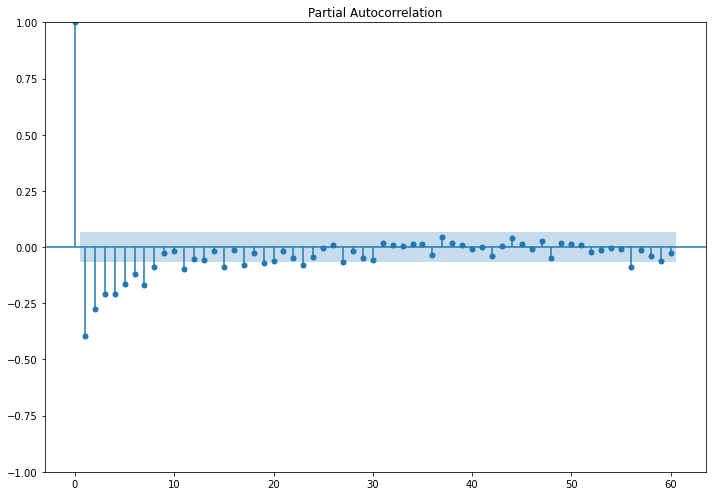

In [74]:
acf_pacf_plotter(res_diff)

The below is all of these functions and things discussed on the real data put into one. We use the true or false result from the adf test to see whether we need to difference.

In [91]:
def full_analysis(data, alpha = 0.05, lags = 60):
    plt.figure(figsize=(20, 7))
    plt.title('Data Series')
    plt.plot(data)
    plt.show()
    print('ADF Test on Data')
    result = adf_test(data, alpha = alpha, lags = lags)
    if result == True:
        acf_pacf_plotter(data, lags = lags)
    else:
        print('Differencing...')
        diff = np.diff(data, 1)
        print('ADF Test on Differenced Data')
        result_diff = adf_test(diff, alpha = alpha, lags = lags)
        if result_diff == True:
            acf_pacf_plotter(diff, lags = lags)
        else:
            print('Residual not stationary: investigate further!')

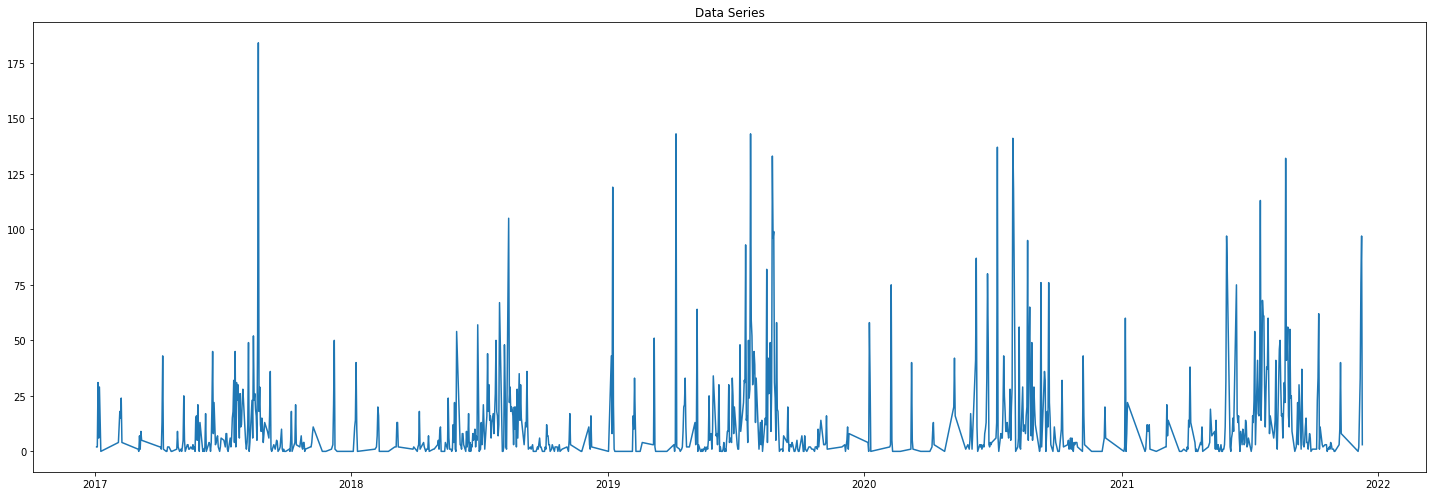

ADF Test on Data
ADF statistic: -1.516380; p-value:0.12143283400172; lags used: 60
Critical Values: {'1%': -2.5683847251149623, '5%': -1.9413217583511693, '10%': -1.6165101639849921}
Data is NON-STATIONARY
Differencing...
ADF Test on Differenced Data
ADF statistic: -5.095876; p-value:0.00000068465490; lags used: 60
Critical Values: {'1%': -2.5683847251149623, '5%': -1.9413217583511693, '10%': -1.6165101639849921}
Data is STATIONARY


C:\Users\Joe_Davies\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


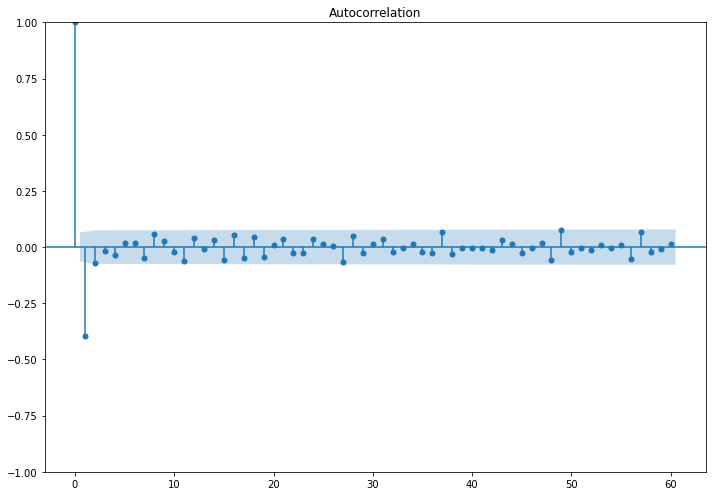

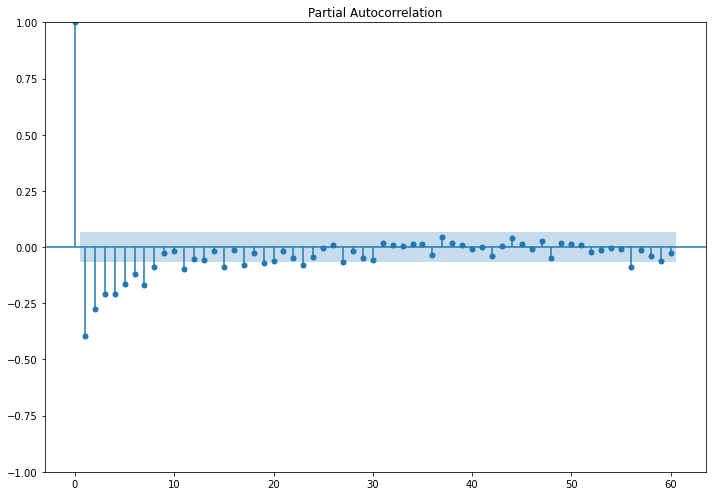

In [92]:
full_analysis(df_date_slice_nona.Rescue)

# Conclusion
We have covered some of the main topics for any early analysis of time series data. In the future we may well want to see whether we can predict the value of the next month's or year's data using more complex models. 